# 🤖 Entrenamiento del Modelo de Machine Learning con Scikit-Learn

**Objetivo:** Este notebook se enfoca en entrenar modelos de Machine Learning (Clasificación Multiclase) utilizando Scikit-Learn. El objetivo es predecir el resultado final de un partido de fútbol:
*   **2:** Victoria Local
*   **1:** Empate
*   **0:** Victoria Visitante

### 1. Importación de Librerías y Algoritmos

En esta celda importamos `pandas` para manipular los datos y `matplotlib` para graficar los resultados de evaluación.

También importamos tres algoritmos clásicos de clasificación de Scikit-Learn para comparar su rendimiento:
*   **Regresión Logística:** Modelo lineal probabilístico.
*   **Random Forest:** Conjunto de árboles de decisión (Ensemble).
*   **Gradient Boosting:** Modelo boosting de árboles secuenciales.

Finalmente importamos métricas como `accuracy_score`, reporte de clasificación y matriz de confusión para evaluar los modelos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Carga del Dataset Procesado

En esta celda cargamos los datos ya filtrados y limpios desde el archivo `partidos_internacionales_limpios.csv` generado anteriormente en el notebook de limpieza. Visualizamos las primeras filas para confirmar que todo esté correcto.

In [2]:
df = pd.read_csv('../datasets/processed/partidos_internacionales_limpios.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (15860, 10)


,date,home_team,away_team,home_score,away_score,tournament,country,neutral,year,tipo_torneo
0,2010-01-02,Iran,North Korea,1,0,Friendly,Qatar,True,2010,amistoso
1,2010-01-02,Qatar,Mali,0,0,Friendly,Qatar,False,2010,amistoso
2,2010-01-02,Syria,Zimbabwe,6,0,Friendly,Malaysia,True,2010,amistoso
3,2010-01-02,Yemen,Tajikistan,0,1,Friendly,Yemen,False,2010,amistoso
4,2010-01-03,Angola,Gambia,1,1,Friendly,Portugal,True,2010,amistoso


## 3. Ingeniería de Variables (Feature Engineering) - Parte 1

Para que nuestro modelo aprenda a predecir, necesitamos crear variables representativas (features) de la fuerza de cada selección:
1.  **resultado:** Nuestra variable objetivo codificada numéricamente (2, 1, 0).
2.  **ataque y defensa:** Calculamos el promedio general de goles a favor y en contra de cada selección para toda la historia reciente, tanto de local como de visitante. El promedio final nos dará un índice relativo de fuerza ofensiva y defensiva por equipo.

In [3]:
# Variable objetivo: resultado del partido
# 2 = gana local, 1 = empate, 0 = gana visitante
def determinar_resultado(row):
    if row['home_score'] > row['away_score']:
        return 2
    elif row['home_score'] == row['away_score']:
        return 1
    else:
        return 0

df['resultado'] = df.apply(determinar_resultado, axis=1)

# Feature: estadísticas históricas de goles por equipo (fuerza de ataque y defensa)
df_home = df.groupby('home_team').agg(
    goles_favor_local=('home_score', 'mean'),
    goles_contra_local=('away_score', 'mean')
).reset_index().rename(columns={'home_team': 'equipo'})

df_away = df.groupby('away_team').agg(
    goles_favor_visit=('away_score', 'mean'),
    goles_contra_visit=('home_score', 'mean')
).reset_index().rename(columns={'away_team': 'equipo'})

estadisticas = pd.merge(df_home, df_away, on='equipo', how='outer').fillna(0)
estadisticas['ataque'] = (estadisticas['goles_favor_local'] + estadisticas['goles_favor_visit']) / 2
estadisticas['defensa'] = (estadisticas['goles_contra_local'] + estadisticas['goles_contra_visit']) / 2
print(estadisticas.head())

        equipo  goles_favor_local  goles_contra_local  goles_favor_visit  \
0     Abkhazia           1.826087            0.565217           1.200000   
1  Afghanistan           1.324324            1.135135           1.000000   
2      Albania           1.134831            1.011236           0.945205   
3     Alderney           0.550000            3.750000           1.000000   
4      Algeria           2.250000            0.777778           1.549451   

   goles_contra_visit    ataque   defensa  
0            1.300000  1.513043  0.932609  
1            1.661290  1.162162  1.398213  
2            1.178082  1.040018  1.094659  
3            4.153846  0.775000  3.951923  
4            1.065934  1.899725  0.921856  


## 4. Ingeniería de Variables (Feature Engineering) - Parte 2

En esta celda:
1.  Hacemos un cruce (merge) para añadir las estadísticas de ataque y defensa de los dos equipos involucrados en cada partido.
2.  Convertimos la variable categórica `neutral` a numérica (`es_neutral`: 0 o 1).
3.  Mapeamos los tipos de torneo a una escala numérica de importancia (`peso_torneo`), asignando mayor relevancia a los Mundiales y Eliminatorias que a los Amistosos.

In [4]:
# Integramos estas estadísticas de ataque y defensa por partido para el equipo local y visitante
df = df.merge(estadisticas[['equipo','ataque','defensa']], left_on='home_team', right_on='equipo', how='left')
df.rename(columns={'ataque': 'ataque_local', 'defensa': 'defensa_local'}, inplace=True)
df.drop(columns=['equipo'], inplace=True)

df = df.merge(estadisticas[['equipo','ataque','defensa']], left_on='away_team', right_on='equipo', how='left')
df.rename(columns={'ataque': 'ataque_visit', 'defensa': 'defensa_visit'}, inplace=True)
df.drop(columns=['equipo'], inplace=True)

# Otras variables adicionales de contexto
df['es_neutral'] = df['neutral'].astype(int)
torneo_map = {'mundial': 4, 'eliminatoria': 3, 'copa_continental': 2, 'amistoso': 1, 'otro': 1}
df['peso_torneo'] = df['tipo_torneo'].map(torneo_map).fillna(1)

FEATURES = ['ataque_local', 'defensa_local', 'ataque_visit', 'defensa_visit', 'es_neutral', 'peso_torneo']
df_modelo = df[FEATURES + ['resultado', 'year']].dropna()
df_modelo.head()

,ataque_local,defensa_local,ataque_visit,defensa_visit,es_neutral,peso_torneo,resultado,year
0,1.932615,0.667453,1.467599,1.183433,1,1,2,2010
1,1.446338,1.237654,1.419531,0.895737,0,1,1,2010
2,1.419540,1.197066,1.252406,1.133921,1,1,2,2010
3,0.890186,1.654907,1.391103,1.294486,0,1,0,2010
4,1.003892,0.929639,1.147755,1.293905,1,1,1,2010


## 5. División Train/Test (Temporal)

Para evitar el sesgo de entrenar con datos del futuro, hacemos una partición temporal estricta:
*   **Train Set:** Todos los partidos disputados hasta el año 2022.
*   **Test Set:** Todos los partidos jugados desde 2023 en adelante. Esto simula cómo se comportará nuestro modelo frente a partidos completamente nuevos en el tiempo.

In [5]:
X = df_modelo[FEATURES]
y = df_modelo['resultado']
years = df_modelo['year']

# Entrenamiento hasta 2022, Prueba con 2023+
X_train = X[years < 2023]
X_test  = X[years >= 2023]
y_train = y[years < 2023]
y_test  = y[years >= 2023]

print(f'Train: {X_train.shape[0]} partidos')
print(f'Test: {X_test.shape[0]} partidos')

Train: 12219 partidos
Test: 3641 partidos


## 6. Entrenamiento y Evaluación de Modelos

En esta celda creamos un diccionario con los tres modelos que elegimos. Ajustamos cada uno de ellos a nuestros datos de entrenamiento (`X_train` e `y_train`), predecimos en el conjunto de prueba (`X_test`) y comparamos su métrica de Accuracy (Precisión Global) para elegir el mejor.

In [6]:
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'{nombre} - Accuracy Test: {acc:.3f}')

Regresión Logística - Accuracy Test: 0.594
Random Forest - Accuracy Test: 0.560
Gradient Boosting - Accuracy Test: 0.601


## 7. Análisis Detallado del Modelo Seleccionado

Evaluamos más a fondo el modelo **Random Forest**.

Generamos un reporte de clasificación detallado que muestra la precisión, recall y F1-score para cada una de las 3 clases posibles (Victoria visitante, Empate y Victoria local).

Además, graficamos la **Matriz de Confusión** para visualizar cuántos resultados se clasificaron correctamente y en cuáles clases el modelo tiende a cometer más errores (típicamente los empates, debido a la alta aleatoriedad).

                precision    recall  f1-score   support

Visitante gana       0.54      0.54      0.54      1079
        Empate       0.29      0.18      0.23       840
    Local gana       0.64      0.76      0.69      1722

      accuracy                           0.56      3641
     macro avg       0.49      0.49      0.49      3641
  weighted avg       0.53      0.56      0.54      3641



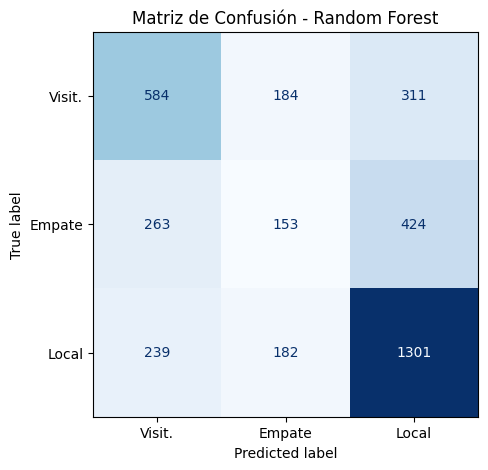

In [7]:
rf = modelos['Random Forest']
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=['Visitante gana','Empate','Local gana']))

fig, ax = plt.subplots(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['Visit.', 'Empate', 'Local'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión - Random Forest')
plt.show()

## 8. Importancia de las Variables (Feature Importance)

El algoritmo Random Forest nos permite calcular la relevancia de cada una de nuestras variables de entrada.

En esta celda, calculamos la importancia relativa de las variables y generamos un gráfico de barras horizontales. Esto nos ayuda a identificar cuáles factores (por ejemplo, la fuerza de ataque o la condición de campo neutral) tienen mayor influencia sobre el resultado final del partido.

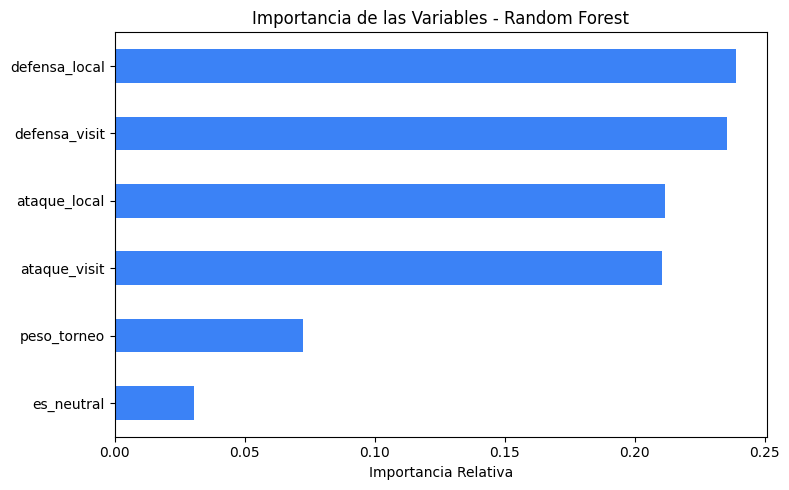

In [8]:
importancias = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8,5))
importancias.plot(kind='barh', ax=ax, color='#3b82f6')
ax.set_title('Importancia de las Variables - Random Forest')
ax.set_xlabel('Importancia Relativa')
plt.tight_layout()
plt.show()

## 9. Simulación de Predicción Completa

Aquí realizamos una predicción práctica.

Definimos una función para recuperar las estadísticas de fuerza de ataque y defensa calculadas para dos países (en este ejemplo, Argentina y Francia) y estructuramos una fila con las variables de entrada correspondientes a un partido de Mundial (neutro = 1, peso = 4). 

Pasamos los datos al Random Forest para estimar el porcentaje probabilístico exacto para cada uno de los tres posibles resultados.

In [9]:
def obtener_stats(equipo, df_stats):
    row = df_stats[df_stats['equipo'] == equipo]
    if len(row) == 0:
        return {'ataque': 1.0, 'defensa': 1.0}
    return {'ataque': row['ataque'].values[0], 'defensa': row['defensa'].values[0]}

stats_arg = obtener_stats('Argentina', estadisticas)
stats_fra = obtener_stats('France', estadisticas)

partido = pd.DataFrame([{
    'ataque_local': stats_arg['ataque'],
    'defensa_local': stats_arg['defensa'],
    'ataque_visit': stats_fra['ataque'],
    'defensa_visit': stats_fra['defensa'],
    'es_neutral': 1,
    'peso_torneo': 4
}])

proba = rf.predict_proba(partido)[0]
print('Probabilidades Argentina vs Francia (Cancha Neutral):')
print(f'Gana Francia: {proba[0]*100:.1f}%')
print(f'Empate:       {proba[1]*100:.1f}%')
print(f'Gana Argentina: {proba[2]*100:.1f}%')

Probabilidades Argentina vs Francia (Cancha Neutral):
Gana Francia: 18.6%
Empate:       67.0%
Gana Argentina: 14.4%


## 10. Exportación del Modelo y Estadísticas

Para poder integrar nuestro modelo en la API web (FastAPI) y la interfaz de usuario interactiva (Streamlit) sin necesidad de volver a ejecutar todo el notebook, exportamos el modelo entrenado y la tabla de estadísticas de los equipos en archivos binarios serializados (`.pkl`) utilizando `joblib`.

In [10]:
import joblib

# Guardamos el modelo Random Forest entrenado
joblib.dump(rf, '../models/modelo_rf.pkl')
print("Modelo Random Forest guardado en models/modelo_rf.pkl")

# Guardamos las estadísticas calculadas de ataque y defensa
joblib.dump(estadisticas, '../models/estadisticas.pkl')
print("Estadísticas guardadas en models/estadisticas.pkl")

Modelo Random Forest guardado en models/modelo_rf.pkl
Estadísticas guardadas en models/estadisticas.pkl
